In [1]:
#Grab Data
import yfinance as yf

#Usual Suspects
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [4]:

# Visualize cumulative returns of each stock in the portfolio
data = pd.read_csv('data/prices.csv',  header=[0,1], index_col=0, parse_dates=True)
close_prices = data['Close']  # Use 'Close' prices from MultiIndex columns
# Simple return
portfolio_returns = close_prices.pct_change().dropna()
port_comps_rets_cumprod = portfolio_returns.add(1).cumprod().sub(1)*100
# log returns
#portfolio_returns = np.log(close_prices / close_prices.shift(1)).dropna()
#port_comps_rets_cumprod = portfolio_returns.cumsum().apply(np.exp).sub(1).mul(100)

fig = px.line(port_comps_rets_cumprod,
              x=port_comps_rets_cumprod.index,
              y=port_comps_rets_cumprod.columns,
              title='Cumulative Returns of Portfolio Stocks (2024-2025)')

fig.update_xaxes(title_text='Date')
fig.update_yaxes(title_text='Cumulative Return in %')

fig.show()

C:\Users\alezu\AppData\Local\Temp\ipykernel_31988\1881219136.py:6: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  portfolio_returns = close_prices.pct_change().dropna()


<Axes: xlabel='Ticker', ylabel='Ticker'>

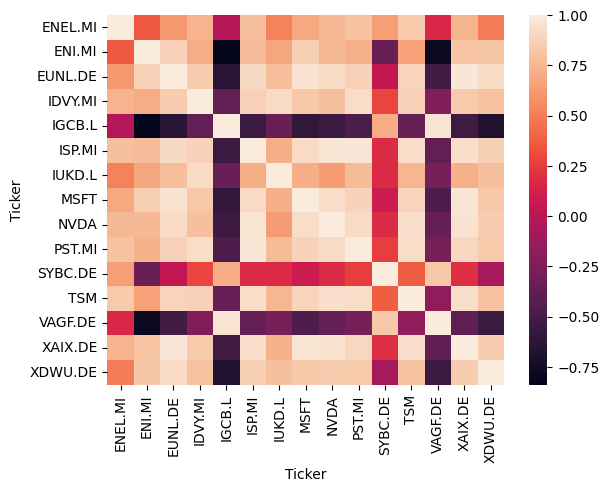

In [12]:
#Create a correlation heatmap to visualize portfolio asset neutrality
port_corr = port_comps_rets_cumprod.corr()

sns.heatmap(port_corr)

In [13]:
from pypfopt import risk_models
from pypfopt import expected_returns
from pypfopt.expected_returns import ema_historical_return
from pypfopt.risk_models import exp_cov
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt.plotting import plot_efficient_frontier
from pypfopt.plotting import plot_weights
from pypfopt.cla import CLA

train = portfolio_returns[:pd.Timestamp("2025-08-28")]
test = portfolio_returns[pd.Timestamp("2025-08-29"):]

mu = expected_returns.ema_historical_return(train, returns_data = True, span = 500)
Sigma = risk_models.exp_cov(train, returns_data = True, span = 180)

rf = 0.02  # 2% annual risk-free rate

In [14]:
mu

Ticker
ENEL.MI    0.252525
ENI.MI     0.191899
EUNL.DE    0.142436
IDVY.MI    0.255971
IGCB.L    -0.003134
ISP.MI     0.591745
IUKD.L     0.146108
MSFT       0.297552
NVDA       1.122205
PST.MI     0.575995
SYBC.DE    0.040533
TSM        0.592519
VAGF.DE    0.021253
XAIX.DE    0.237822
XDWU.DE    0.116078
Name: 2025-08-28 00:00:00, dtype: float64

In [15]:
max_return = mu.max()
ret_ef = np.arange(0, max_return, 0.03)
vol_ef = []
for i in ret_ef:
    ef = EfficientFrontier(mu, Sigma)
    ef.efficient_return(i)
    vol_ef.append(ef.portfolio_performance(risk_free_rate=rf)[1])

In [16]:
ef = EfficientFrontier(mu, Sigma)
ef.min_volatility()
min_vol_ret = ef.portfolio_performance(verbose=True, risk_free_rate=rf)[0]
min_vol_vol = ef.portfolio_performance(risk_free_rate=rf)[1]

Expected annual return: 4.7%
Annual volatility: 2.7%
Sharpe Ratio: 0.99


In [17]:
ef = EfficientFrontier(mu, Sigma)
ef.max_sharpe(risk_free_rate=rf)
max_sharpe_ret = ef.portfolio_performance(verbose=True, risk_free_rate=rf)[0]
max_sharpe_vol = ef.portfolio_performance( risk_free_rate=rf)[1]

Expected annual return: 55.9%
Annual volatility: 12.3%
Sharpe Ratio: 4.37


Text(0.5, 1.0, 'Efficient Frontier')

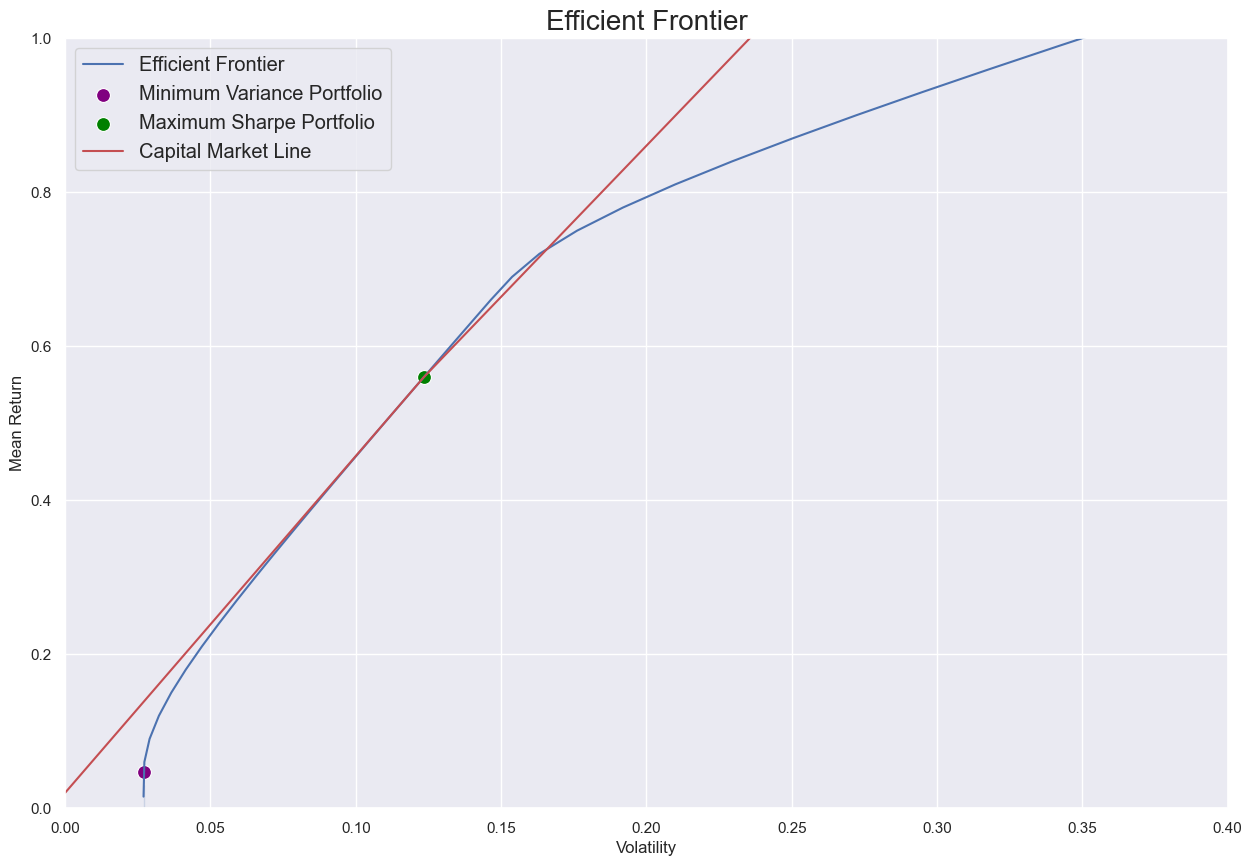

In [18]:
sns.set()

fig, ax = plt.subplots(figsize = [15,10])

sns.lineplot(x = vol_ef, y = ret_ef,
             label = "Efficient Frontier",
             ax = ax)

sns.scatterplot(x = [min_vol_vol], y = [min_vol_ret],
                ax = ax,
                label = "Minimum Variance Portfolio",
                color = "purple", s = 100)

sns.scatterplot(x = [max_sharpe_vol], y = [max_sharpe_ret],
                ax = ax,
                label = "Maximum Sharpe Portfolio",
                color = "green", s = 100)

sns.lineplot(x = [0, max_sharpe_vol,1], y = [rf, max_sharpe_ret, 4],
             label = "Capital Market Line",
             ax = ax,
             color = "r")

ax.set(xlim = [0, 0.4])
ax.set(ylim = [0, 1])
ax.set_xlabel("Volatility")
ax.set_ylabel("Mean Return")
plt.legend(fontsize='large')
plt.title("Efficient Frontier", fontsize = '20')

Expected annual return: 4.7%
Annual volatility: 2.7%
Sharpe Ratio: 0.99


(np.float64(0.04663416880041148),
 np.float64(0.02698163807056131),
 np.float64(0.987122009818635))

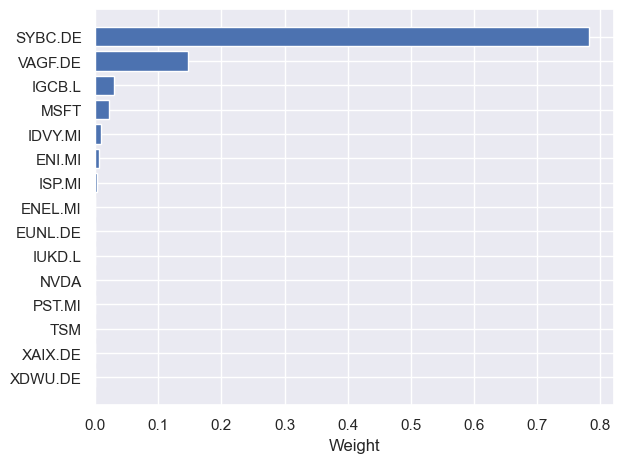

In [19]:
# Minimum Variance
ef = EfficientFrontier(mu, Sigma)
raw_weights_minvar_exp = ef.min_volatility()

plot_weights(raw_weights_minvar_exp)
ef.portfolio_performance(verbose = True, risk_free_rate = rf)

Expected annual return: 55.9%
Annual volatility: 12.3%
Sharpe Ratio: 4.37


(np.float64(0.5593951147379299),
 np.float64(0.12333992679183754),
 np.float64(4.373240107789867))

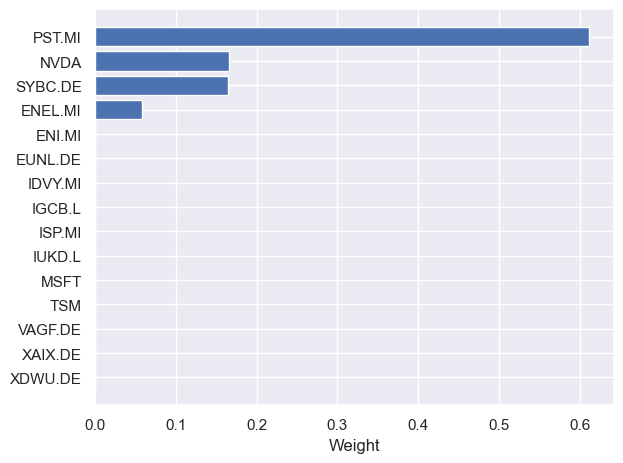

In [20]:
# Maximum Sharpe
ef = EfficientFrontier(mu, Sigma)
raw_weights_maxsharpe_exp = ef.max_sharpe(risk_free_rate=rf)

plot_weights(raw_weights_maxsharpe_exp)
ef.portfolio_performance(verbose = True, risk_free_rate = rf)

In [ ]:
#Import S&P500 data and plot cum_returns for performance comparison
sp_index = yf.download('^GSPC', start="2022-01-01", end="2025-09-01")
sp_index.head()
#if sp_index is not None:
   # sp_index.to_csv('sp_index.csv', index=False)
#else:
   # print(f"No data , skipping CSV export.")


In [ ]:
weights_minvar_exp = list(raw_weights_minvar_exp.values())
weights_maxsharpe_exp = list(raw_weights_maxsharpe_exp.values())

ret_1 = test.dot(weights_minvar_exp).add(1).cumprod().subtract(1).multiply(100)
ret_2 = test.dot(weights_maxsharpe_exp).add(1).cumprod().subtract(1).multiply(100)
ind_ret = sp_index["2025-09-01":]['Close'].pct_change().add(1).cumprod().subtract(1).multiply(100)



In [ ]:
print(raw_weights_maxsharpe_exp)

In [ ]:
back = pd.DataFrame({"MinVar":ret_1, "MaxSharpe":ret_2})
back = pd.concat([back, ind_ret],  join = "outer", axis = 1)
back.drop(back.tail(1).index,inplace=True)

back.interpolate(method = "linear", inplace = True)
print(back)
fig = px.line(back, title="Portfolio Performance")
fig.update_xaxes(title_text='Date')
fig.update_yaxes(title_text='Cumulative Return in %')

fig.show()